![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación de librerías
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [ ]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [ ]:
# Celda 1.1
bikes.groupby('season').total.mean()

,total
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [ ]:
# Celda 1.2
bikes.groupby('hour').total.mean()

,total
hour,
0,55.138462
1,33.859031
2,22.899554
3,11.757506
4,6.407240
5,19.767699
6,76.259341
7,213.116484
8,362.769231


In [ ]:
bikes.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,23.000000


In [ ]:
bikes[["season", "hour"]].describe(percentiles=[0.25, 0.5, 0.75])



,season,hour
count,10886.000000,10886.000000
mean,2.506614,11.541613
std,1.116174,6.915838
min,1.000000,0.000000
25%,2.000000,6.000000
50%,3.000000,12.000000
75%,4.000000,18.000000
max,4.000000,23.000000


En el caso de la columna season, se observa que se refiere a las cuatro estaciones del año. En cuanto a la columna de hora, a las 24 horas del día. En este caso, se da cuenta de que el percentil 25 es 6 y el 75 es 18, lo que significa que el 50% central de los registros ocurre entre las 6am y las 6pm; es decir, hay más actividad registrada durante el día.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

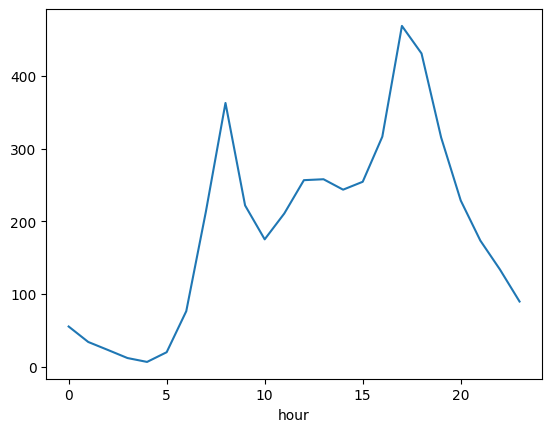

In [ ]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

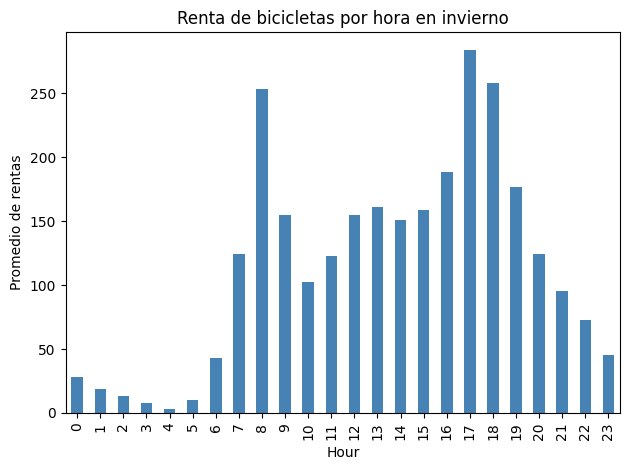

In [ ]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos
invierno = bikes[bikes["season"] == 1].groupby("hour")["total"].mean()

invierno.plot(kind="bar", title="Renta de bicicletas por hora en invierno",
            xlabel="Hour", ylabel="Promedio de rentas", color="steelblue")
plt.tight_layout()
plt.show()

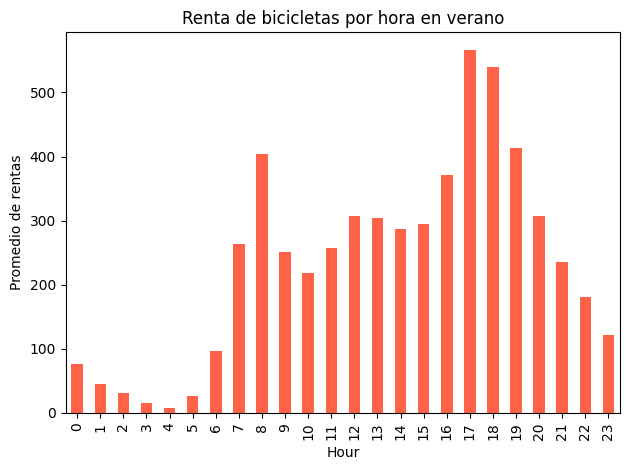

In [ ]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
Verano = bikes[bikes["season"] == 3].groupby("hour")["total"].mean()

Verano.plot(kind="bar", title="Renta de bicicletas por hora en verano",
            xlabel="Hour", ylabel="Promedio de rentas", color="tomato")
plt.tight_layout()
plt.show()

Ambos gráficos son consistentes con las rentas promedio. Se observa que el pico de rentas se da entre las 16 y las 18 horas, y el valle a las 4. El promedio de rentas es significativamente mayor en verano que en invierno, lo que puede obedecer al hecho de que es una estación más propicia para el ciclismo. Igualmente, el pico menor entre las 7 y las 9 horas, sumado al principal, puede indicar que las personas rentan bicicletas como modo de transporte para desplazarse hacia y desde sus lugares de trabajo.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [29]:
# Celda 3
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

X3 = bikes[["season", "hour"]]
y3 = bikes["total"]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first"), ["season"]),
    ("num", "passthrough", ["hour"])
])

X3_train_processed = preprocessor.fit_transform(X3_train)
X3_test_processed  = preprocessor.transform(X3_test)

#Modelo
model = LinearRegression()
model.fit(X3_train_processed, y3_train)

#Coeficientes
season_categories = preprocessor.named_transformers_["cat"].get_feature_names_out(["season"])
feature_names = list(season_categories) + ["hour"]

print("Intercepto:", model.intercept_)
print("\nCoeficientes:")
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name}: {coef:.4f}")

# Métricas
y3_pred = model.predict(X3_test_processed)
mse_lr  = mean_squared_error(y3_test, y3_pred)
rmse_lr = np.sqrt(mse_lr)
print(f"\nMSE: {mse_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")

Intercepto: -5.919547341961646

Coeficientes:
  season_2: 99.1067
  season_3: 116.0463
  season_4: 84.9448
  hour: 10.5696

MSE: 25409.92
RMSE: 159.40


Hour: 10.5696 significa que, por cada hora adicional, el promedio de bicicletas rentadas aumenta en aproximadamente 10.57 unidades, mientras que season_2: 99.1067 indica que, en la estación 2, el promedio de bicicletas rentadas es 99.11 unidades más alto que en la estación de referencia (estación 1), manteniendo la hora constante.

Ya que el intercepto representa el valor predicho de total cuando todas las variables predictoras son cero: cuando es invierno (season 1, la categoría base) y la hora es la 0 (medianoche). Un valor de -5.92 bicicletas es imposible en la realidad, por un lado. Por el otro, la relación entre ambas variables no es lineal, por lo que el modelo no es el apropiado para la distribución de los datos.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [ ]:
# Celda 4
print(bikes.groupby('hour').total.mean())
print(bikes.groupby('season').total.mean())

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64
season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64


In [ ]:
leaf1 = bikes[(bikes['hour'] < 8)  & (bikes['season'] == 1)]['total'].mean()
leaf2 = bikes[(bikes['hour'] < 8)  & (bikes['season'] != 1)]['total'].mean()
leaf3 = bikes[(bikes['hour'] >= 8) & (bikes['hour'] <= 19) & (bikes['season'] == 1)]['total'].mean()
leaf4 = bikes[(bikes['hour'] >= 8) & (bikes['hour'] <= 19) & (bikes['season'] != 1)]['total'].mean()
leaf5 = bikes[(bikes['hour'] >= 20) & (bikes['season'] == 1)]['total'].mean()
leaf6 = bikes[(bikes['hour'] >= 20) & (bikes['season'] != 1)]['total'].mean()

print(f"Hoja 1 (hour<8,  invierno):      {leaf1:.2f}")
print(f"Hoja 2 (hour<8,  otras seasons): {leaf2:.2f}")
print(f"Hoja 3 (8<=hour<=19, invierno):  {leaf3:.2f}")
print(f"Hoja 4 (8<=hour<=19, otras):     {leaf4:.2f}")
print(f"Hoja 5 (hour>=20, invierno):     {leaf5:.2f}")
print(f"Hoja 6 (hour>=20, otras):        {leaf6:.2f}")

Hoja 1 (hour<8,  invierno):      32.14
Hoja 2 (hour<8,  otras seasons): 62.83
Hoja 3 (8<=hour<=19, invierno):  180.45
Hoja 4 (8<=hour<=19, otras):     330.19
Hoja 5 (hour>=20, invierno):     84.48
Hoja 6 (hour>=20, otras):        180.16


In [ ]:
def manual_tree(hour, season):
    if hour < 8:
        return leaf1 if season == 1 else leaf2
    elif hour <= 19:
        return leaf3 if season == 1 else leaf4
    else:
        return leaf5 if season == 1 else leaf6

bikes['tree_pred'] = bikes.apply(lambda row: manual_tree(row['hour'], row['season']), axis=1)

In [ ]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(bikes['total'], bikes['tree_pred']))
print(f"\nRMSE del árbol manual: {rmse:.2f}")


RMSE del árbol manual: 137.40


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [ ]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
X = bikes[["season", "hour"]]
y = bikes["total"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first"), ["season"]),
    ("num", "passthrough", ["hour"])
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("tree", DecisionTreeRegressor(random_state=42))
])

param_grid = {
    "tree__max_depth": [3, 5, 7, 10, None],
    "tree__min_samples_leaf": [1, 5, 10, 20],
    "tree__criterion": ["squared_error"]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor RMSE en CV (train): {-grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"\nRMSE en validación (árbol sklearn): {rmse_val:.2f}")

Mejores parámetros: {'tree__criterion': 'squared_error', 'tree__max_depth': 10, 'tree__min_samples_leaf': 1}
Mejor RMSE en CV (train): 113.73

RMSE en validación (árbol sklearn): 116.00


Se observa que el RMSE en CV y en validación para el árbol de decisión en sklearn es de 113.73 y 116, respectivamente. Este es un contraste significativo con el RMSE del modelo de regresión lineal explorado anteriormente, de 159.40, lo cual demuestra que el árbol de decisión es mucho mejor que la regresión lineal para explicar la relación entre los datos.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [ ]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [ ]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [ ]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [ ]:
# Celda 6
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

tree = DecisionTreeClassifier(max_depth=5, random_state=1)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Árbol de decisión")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tree):.4f}")

#Regresión logística
lr = LogisticRegression(max_iter=1000, random_state=1)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nRegresión logística")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

Árbol de decisión
Accuracy: 0.6373
F1-Score: 0.6617

Regresión logística
Accuracy: 0.6133
F1-Score: 0.6033


En lo referente a la exactitud, se observa que el árbol acierta el 63.73% de la popularidad de las noticias, mientras que la regresión logística acierta el 61.33%. Con respecto al F1-Score, se tiene que el árbol tiene un puntaje de 66.17% y la regresión uno de 60.3%.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados.

Nota:

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [ ]:
# Celda 7
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score

In [23]:
all_preds = np.zeros((len(X_test), 300))

#Primeras 100
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(max_depth=5, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, i] = model.predict(X_test)

#Segundas 100
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, 100 + i] = model.predict(X_test)

#Últimas 100
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = LogisticRegression(max_iter=1000, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, 200 + i] = model.predict(X_test)

In [24]:
y_pred_ensemble = (all_preds.mean(axis=1) > 0.5).astype(int)

print("Ensamble: Votación Mayoritaria (300 modelos)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_ensemble):.4f}")

Ensamble: Votación Mayoritaria (300 modelos)
Accuracy: 0.6400
F1-Score: 0.6317


In [25]:
for nombre, cols in [("Árboles max_depth=5", range(0,100)),
                     ("Árboles min_samples_leaf=10", range(100,200)),
                     ("Regresiones logísticas", range(200,300))]:
    y_pred_grupo = (all_preds[:, cols].mean(axis=1) > 0.5).astype(int)
    print(f"\n{nombre}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_grupo):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_grupo):.4f}")


Árboles max_depth=5
Accuracy: 0.6500
F1-Score: 0.6465

Árboles min_samples_leaf=10
Accuracy: 0.6573
F1-Score: 0.6508

Regresiones logísticas
Accuracy: 0.6173
F1-Score: 0.6052


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [26]:
# Celda 8
weights = np.zeros(300)

#Primeras 100
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(max_depth=5, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, i] = model.predict(X_test)
    weights[i] = accuracy_score(y_test, all_preds[:, i])

#Segundas 100
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, 100 + i] = model.predict(X_test)
    weights[100 + i] = accuracy_score(y_test, all_preds[:, 100 + i])

#Últimas 100:
for i in range(100):
    X_bs, y_bs = resample(X_train, y_train, random_state=i)
    model = LogisticRegression(max_iter=1000, random_state=i)
    model.fit(X_bs, y_bs)
    all_preds[:, 200 + i] = model.predict(X_test)
    weights[200 + i] = accuracy_score(y_test, all_preds[:, 200 + i])

In [30]:
weighted_avg = np.average(all_preds, axis=1, weights=weights)
y_pred_weighted = (weighted_avg > 0.5).astype(int)

print("Ensamble: Votación Ponderada (300 modelos)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_weighted):.4f}")

Ensamble: Votación Ponderada (300 modelos)
Accuracy: 0.6387
F1-Score: 0.6308


Para la votación ponderada, la exactitud del ensamble es de 63.87%, y el F1-Score de 63.8%.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [28]:
# Celda 9

En cuanto a la exactitud de ambos modelos, se observa una ligera disminución en la votación ponderada con respecto a la votación mayoritaria (de 64% a 63.87%). Es igualmente el caso del F1-Score, que pasa de 63.17% a 63.08%.

Es de notar que ambas tienen un desempeño inferior en el F1-Score con respecto al árbol de decisión individual, que arrojó una métrica de 66.17%.

Como ventajas de la votación mayoritaria, se destaca su interpretabilidad y su robustez frente al hecho de que algún modelo sea deficiente, ya que puede cancelarse su efecto con los demás. Por su parte, esto también es una desventaja, ya que trata a todos los modelos como iguales, sin importar su rendimiento.

Por parte de la votación ponderada, le da más influencia a los modelos que mejor predicen, lo que, en teoría, debería mejorar el resultado final. Además, es más compleja de implementar y menos transparente que la votación simple.
En este caso en particular, no se observan diferencias sustanciales en las métricas de ambas votaciones, por lo que la ponderación prácticamente no cambia nada respecto a la votación simple.
